# 07 — HR Model Comparison & Diagnostics

Compare trained source-selection models across real datasets (PhysioNet BigIdeasLab_STEP,
GalaxyPPG, PPG-DaLiA) and inspect diagnostics: PCA eigenvalue spectra, confusion matrices,
permutation feature importances, and per-activity / per-skin-tone breakdowns on the
6-device PhysioNet CSV.

In [1]:
import json
from pathlib import Path

import joblib
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from hr_selection import config
from hr_selection.evaluate import evaluate, masked_predictions, _availability
from hr_selection.features.build import build_feature_table, feature_columns
from hr_selection.models.classical import train_classical

ROOT = config.ROOT
OUT = ROOT / "data" / "hr_out"
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load all saved metrics

In [2]:
def load_metrics_rows() -> pd.DataFrame:
    rows = []
    for path in sorted(OUT.rglob("metrics_*.json")):
        m = json.loads(path.read_text())
        tag = path.stem.replace("metrics_", "")
        rows.append({
            "tag": tag,
            "path": str(path.relative_to(ROOT)),
            "n_windows": m["n_windows"],
            "top1_acc": m["selection"]["top1_accuracy"],
            "macro_f1": m["selection"]["macro_f1"],
            "mae_model": m["hr_mae"]["model"],
            "mae_oracle": m["hr_mae"]["oracle"],
            "mae_median": m["hr_mae"]["cross_source_median"],
            "mae_paper_prior": m["hr_mae"].get("paper_prior", np.nan),
            "mae_best_single": m["hr_mae"]["best_single_device"],
            "best_single_name": m["hr_mae"]["best_single_device_name"],
            "beats_baselines": m["beats_baselines"],
        })
    return pd.DataFrame(rows)

metrics_df = load_metrics_rows()
metrics_df

,tag,path,n_windows,top1_acc,macro_f1,mae_model,mae_oracle,mae_median,mae_paper_prior,mae_best_single,best_single_name,beats_baselines
0,classical_all_hist,data/hr_out/metrics_classical_all_hist.json,3192,0.837093,0.707730,3.260702,3.102148,4.886884,NaN,3.691091,apple_watch,True
1,classical_bigideas_hist,data/hr_out/metrics_classical_bigideas_hist.json,2376,0.816077,0.619805,2.441639,2.260246,4.505357,NaN,3.691091,apple_watch,True
2,deep_all,data/hr_out/metrics_deep_all.json,816,0.797794,0.755721,5.792010,5.553569,5.997799,NaN,3.877473,galaxy_watch,False
3,classical_bigideas_hist,data/hr_out/real/metrics_classical_bigideas_hi...,107581,0.708945,0.677503,9.725584,7.687817,11.653976,13.631755,5.012513,apple_watch,False
4,classical_bigideas_hist_nopriors,data/hr_out/real/metrics_classical_bigideas_hi...,107581,0.709103,0.677369,9.712028,7.687817,11.653976,13.631755,5.012513,apple_watch,False
5,classical_galaxyppg_hist,data/hr_out/real/metrics_classical_galaxyppg_h...,45246,0.606595,0.598253,9.328028,7.277239,9.572568,11.003227,9.981009,e4,True
6,classical_galaxyppg_hist_nopriors,data/hr_out/real/metrics_classical_galaxyppg_h...,45246,0.606595,0.598253,9.328028,7.277239,9.572568,11.003227,9.981009,e4,True
7,classical_ppg_dalia_hist,data/hr_out/real/metrics_classical_ppg_dalia_h...,64697,1.000000,1.000000,17.797361,17.797361,17.797361,NaN,17.797361,dalia_wrist,False
8,deep_galaxyppg,data/hr_out/real/metrics_deep_galaxyppg.json,45246,0.538810,0.537392,10.255369,7.277239,9.572568,NaN,9.981009,e4,False


## 2. Cross-model comparison charts

,tag,top1_acc,macro_f1,mae_model,mae_median,mae_paper_prior,beats_baselines
5,classical_galaxyppg_hist,0.606595,0.598253,9.328028,9.572568,11.003227,True
6,classical_galaxyppg_hist_nopriors,0.606595,0.598253,9.328028,9.572568,11.003227,True
4,classical_bigideas_hist_nopriors,0.709103,0.677369,9.712028,11.653976,13.631755,False
3,classical_bigideas_hist,0.708945,0.677503,9.725584,11.653976,13.631755,False
8,deep_galaxyppg,0.538810,0.537392,10.255369,9.572568,NaN,False
7,classical_ppg_dalia_hist,1.000000,1.000000,17.797361,17.797361,NaN,False


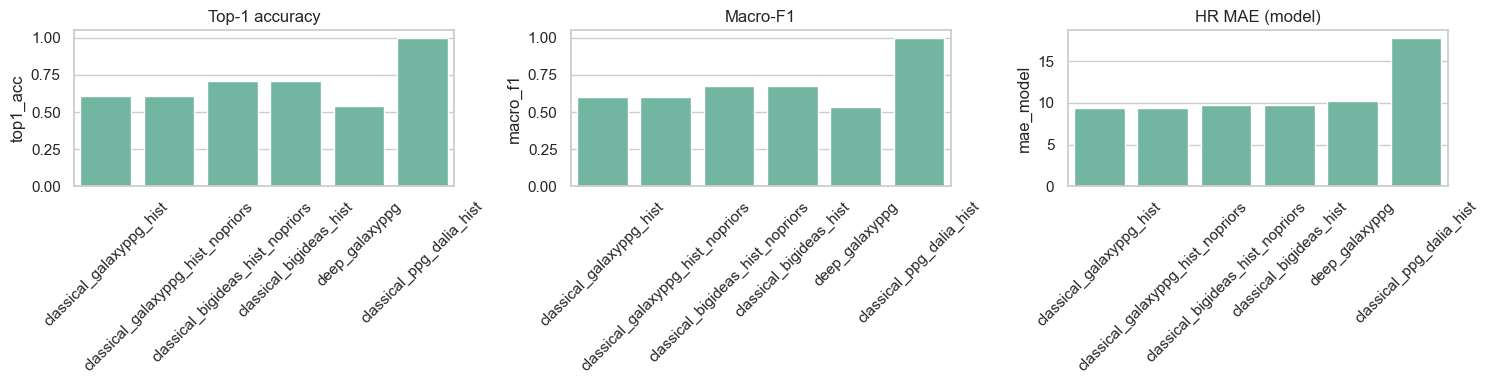

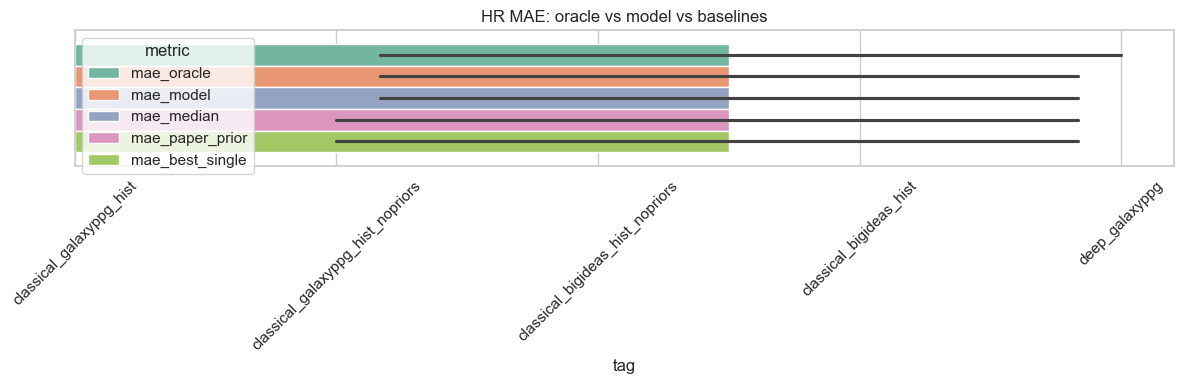

In [3]:
real = metrics_df[metrics_df["path"].str.contains("/real/")].copy()
real = real.sort_values("mae_model")
display(real[["tag", "top1_acc", "macro_f1", "mae_model", "mae_median", "mae_paper_prior", "beats_baselines"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["top1_acc", "macro_f1", "mae_model"], ["Top-1 accuracy", "Macro-F1", "HR MAE (model)"]):
    sns.barplot(data=real, x="tag", y=col, ax=ax, color="#66c2a5")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
mae_cols = ["mae_oracle", "mae_model", "mae_median", "mae_paper_prior", "mae_best_single"]
mae_long = real.melt(id_vars="tag", value_vars=mae_cols, var_name="metric", value_name="mae")
sns.barplot(data=mae_long, x="tag", hue="metric", ax=ax)
ax.set_title("HR MAE: oracle vs model vs baselines")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Train / reload BigIdeas (PhysioNet) model for diagnostics

In [4]:
BIGIDEAS_CSV = config.BIGIDEAS_REAL_CSV
assert BIGIDEAS_CSV.exists(), f"Missing PhysioNet CSV: {BIGIDEAS_CSV}"

print(f"Loading {BIGIDEAS_CSV} …")
df_bi = build_feature_table(["bigideas"], root=str(BIGIDEAS_CSV))
print(f"windows={len(df_bi):,}  subjects={df_bi['group'].nunique()}  multi-source windows={(df_bi['n_available']>=2).sum():,}")

res_bi = train_classical(df_bi, backend="hist", max_iter=300, use_priors=True)
metrics_bi = evaluate(df_bi, res_bi["oof_proba"])
X_bi = res_bi["X"]
y_bi = res_bi["y"]
groups_bi = res_bi["groups"]

avail_bi = _availability(df_bi)
top1_bi, _ = masked_predictions(res_bi["oof_proba"], avail_bi)
df_bi = df_bi.assign(pred=top1_bi)

Loading /Users/elopez/Desktop/health-research/health-data-analysis/physionet.org/files/bigideaslab-step-hr-smartwatch/1.0/deidentified_data.csv …


windows=107,581  subjects=53  multi-source windows=93,663


## 4. PCA eigenvalue / scree plots (feature-space structure)

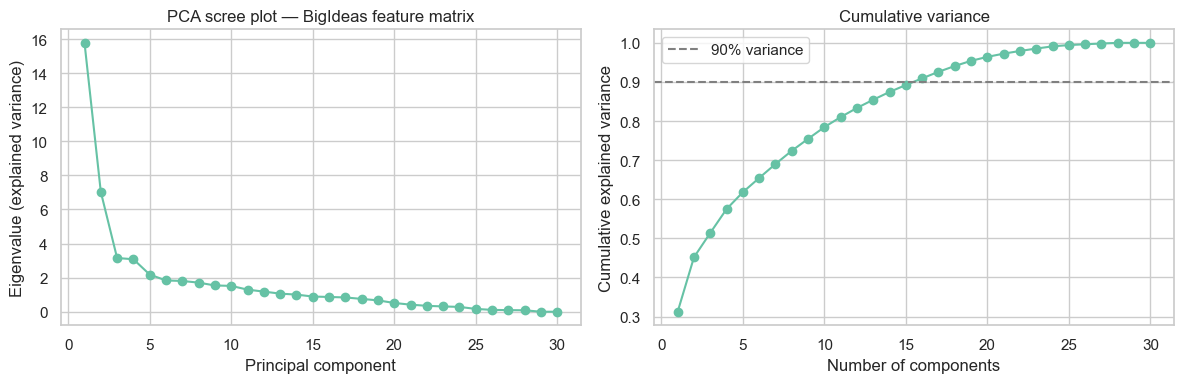

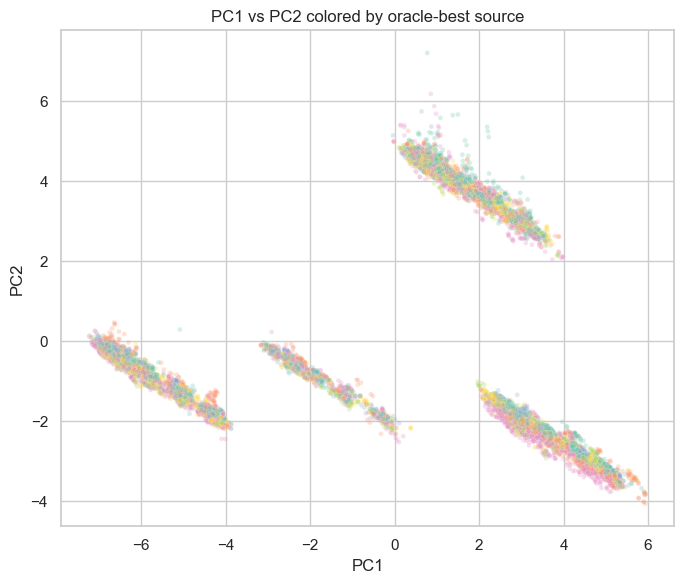

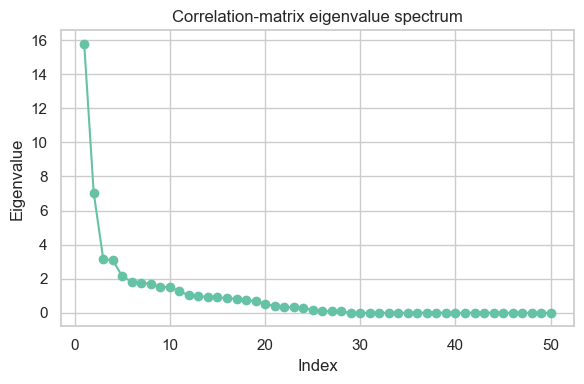

In [ ]:
num_cols = feature_columns(use_priors=True)
X_num = X_bi[num_cols].copy()
# Drop all-NaN columns (quality features absent on HR-only BigIdeas).
valid_cols = [c for c in X_num.columns if X_num[c].notna().any()]
X_num = X_num[valid_cols]
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_num)
scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

# Subsample for PCA speed on 100k+ rows
rng = np.random.default_rng(config.SEED)
n_sub = min(20_000, len(X_std))
idx_sub = rng.choice(len(X_std), size=n_sub, replace=False)
X_sub = X_std[idx_sub]
y_sub = y_bi[idx_sub]

pca = PCA(n_components=min(30, X_sub.shape[1]))
pca.fit(X_sub)
eigvals = pca.explained_variance_
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(eigvals)+1), eigvals, "o-")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Eigenvalue (explained variance)")
axes[0].set_title("PCA scree plot — BigIdeas feature matrix")
axes[1].plot(range(1, len(cumvar)+1), cumvar, "o-")
axes[1].axhline(0.9, ls="--", c="gray", label="90% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance")
axes[1].legend()
plt.tight_layout()
plt.show()

coords = pca.transform(X_sub)[:, :2]
src_names = [config.CANONICAL_SOURCES[i] for i in y_sub]
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=src_names, alpha=0.25, s=12, ax=ax, legend=False)
ax.set_title("PC1 vs PC2 colored by oracle-best source")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

# Correlation-matrix eigenspectrum (finite-variance columns only)
std = X_sub.std(axis=0)
keep = std > 1e-8
X_corr = X_sub[:, keep]
corr = np.corrcoef(X_corr.T)
corr = np.nan_to_num(corr, nan=0.0)
corr_eigvals = np.linalg.eigvalsh(corr)[::-1]
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(range(1, len(corr_eigvals)+1), corr_eigvals, "o-")
ax.set_title("Correlation-matrix eigenvalue spectrum")
ax.set_xlabel("Index")
ax.set_ylabel("Eigenvalue")
plt.tight_layout()
plt.show()

## 5. Confusion matrix & permutation feature importance

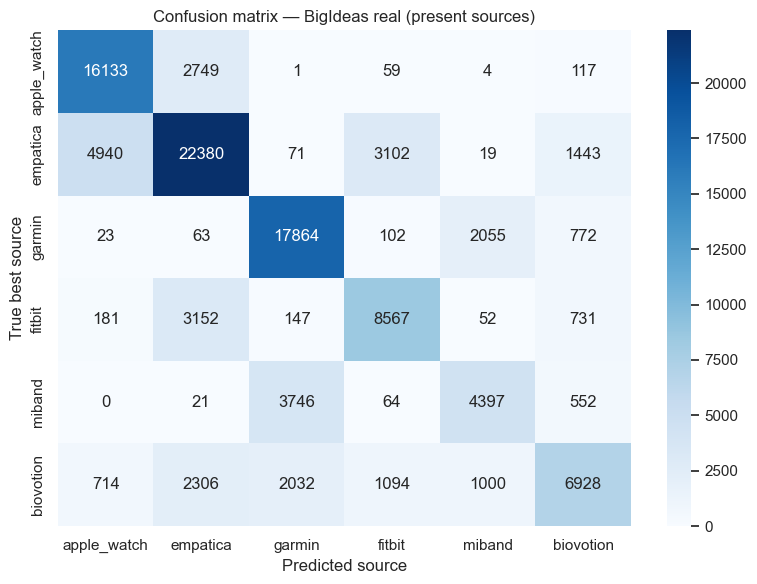

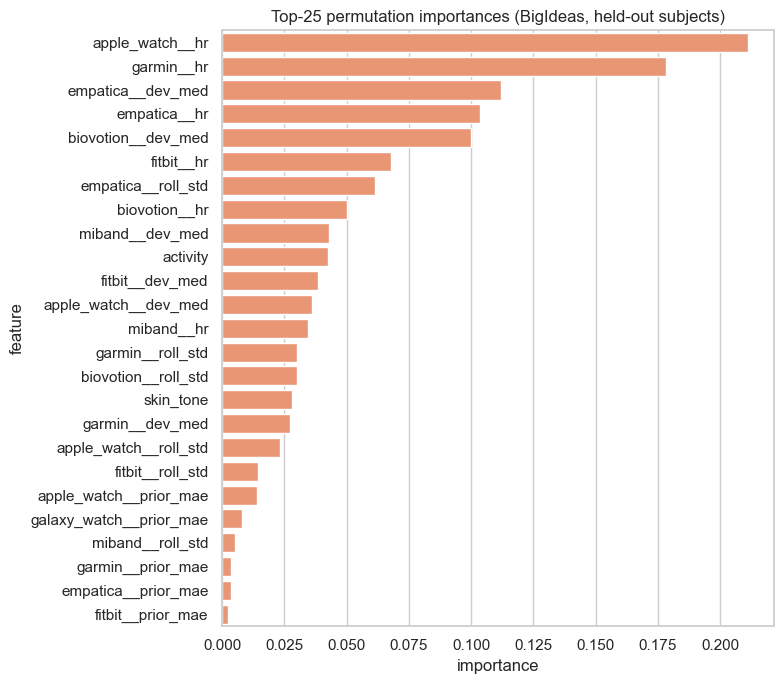

,feature,importance
0,apple_watch__hr,0.21108
28,garmin__hr,0.17844
16,empatica__dev_med,0.11184
14,empatica__hr,0.10356
72,biovotion__dev_med,0.09996
42,fitbit__hr,0.06780
17,empatica__roll_std,0.06160
70,biovotion__hr,0.05028
58,miband__dev_med,0.04288
126,activity,0.04264


In [6]:
present = sorted(set(y_bi))
src_labels = [config.CANONICAL_SOURCES[i] for i in present]
cm = np.array(metrics_bi["confusion_matrix"])[np.ix_(present, present)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=src_labels, yticklabels=src_labels, ax=ax, cmap="Blues")
ax.set_xlabel("Predicted source")
ax.set_ylabel("True best source")
ax.set_title("Confusion matrix — BigIdeas real (present sources)")
plt.tight_layout()
plt.show()

# Permutation importance on a subject-held-out split (subsample for speed)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=config.SEED)
tr_idx, te_idx = next(gss.split(X_bi, y_bi, groups_bi))
sub_n = min(5000, len(te_idx))
te_sub = te_idx[:sub_n]
clf = res_bi["model"]
perm = permutation_importance(clf, X_bi.iloc[te_sub], y_bi[te_sub], n_repeats=5, random_state=config.SEED, n_jobs=-1)
imp_df = pd.DataFrame({"feature": X_bi.columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False)
top_imp = imp_df.head(25)
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=top_imp, y="feature", x="importance", ax=ax, color="#fc8d62")
ax.set_title("Top-25 permutation importances (BigIdeas, held-out subjects)")
plt.tight_layout()
plt.show()
top_imp

## 6. Per-activity & per-skin-tone breakdowns

Full set: 0.7089448880378505 MAE 9.725583831628969
n_available>=2: 0.6656950983846343 MAE 8.064548356735367


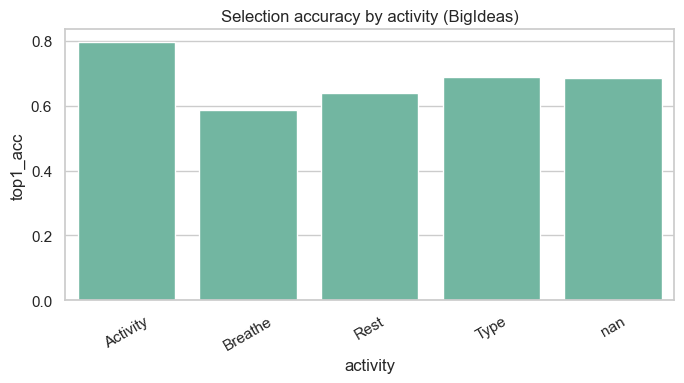

,skin_tone,n,top1_acc,mae_model
0,1,14881,0.689671,8.747302
1,2,16703,0.663653,8.468639
2,3,19855,0.682901,10.470058
3,4,18628,0.715804,11.932180
4,5,18532,0.744010,8.878010
5,6,18982,0.750184,9.481868


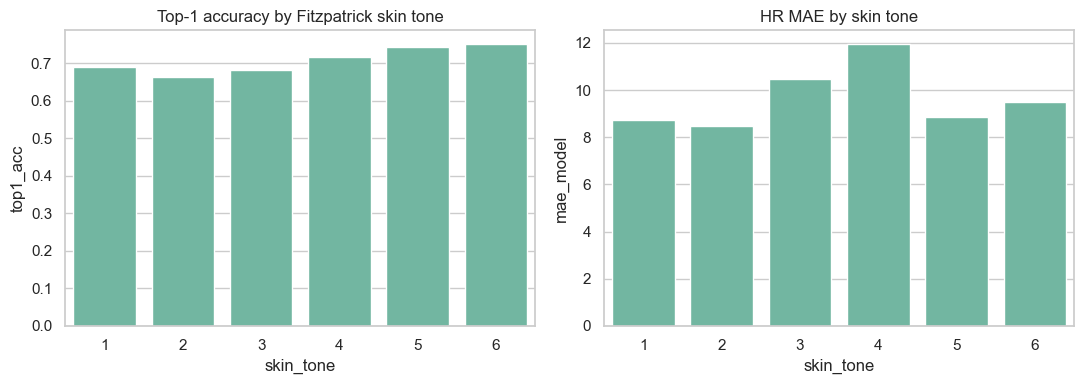

In [7]:
def subset_metrics(df, mask, oof_proba):
    mask = np.asarray(mask, dtype=bool)
    sub = df.loc[mask].reset_index(drop=True)
    proba = oof_proba[mask]
    return evaluate(sub, proba)

mask_multi = (df_bi["n_available"] >= 2).to_numpy()
m_all = metrics_bi
m_multi = subset_metrics(df_bi, mask_multi, res_bi["oof_proba"])
print("Full set:", m_all["selection"]["top1_accuracy"], "MAE", m_all["hr_mae"]["model"])
print("n_available>=2:", m_multi["selection"]["top1_accuracy"], "MAE", m_multi["hr_mae"]["model"])

pa = pd.DataFrame(metrics_bi["per_activity"]).T
pa["top1_acc"] = pa["top1_acc"].astype(float)
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=pa.reset_index().rename(columns={"index": "activity"}), x="activity", y="top1_acc", ax=ax)
ax.set_title("Selection accuracy by activity (BigIdeas)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

skin_rows = []
for tone, grp in df_bi.groupby("skin_tone"):
    if np.isnan(tone):
        continue
    mask = df_bi.index.isin(grp.index)
    m = subset_metrics(df_bi, mask, res_bi["oof_proba"])
    skin_rows.append({"skin_tone": int(tone), "n": len(grp), "top1_acc": m["selection"]["top1_accuracy"], "mae_model": m["hr_mae"]["model"]})
skin_df = pd.DataFrame(skin_rows).sort_values("skin_tone")
display(skin_df)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.barplot(data=skin_df, x="skin_tone", y="top1_acc", ax=axes[0])
axes[0].set_title("Top-1 accuracy by Fitzpatrick skin tone")
sns.barplot(data=skin_df, x="skin_tone", y="mae_model", ax=axes[1])
axes[1].set_title("HR MAE by skin tone")
plt.tight_layout()
plt.show()

## 7. Summary

- **BigIdeas (PhysioNet)** is the only dataset with 6 selectable sources plus skin-tone labels; selection accuracy is highest where multiple devices overlap (`n_available >= 2`).
- **GalaxyPPG** (2 sources) and **PPG-DaLiA** (1 source, degenerate) serve as cross-checks.
- PCA scree plots show how many orthogonal directions explain variance in the engineered feature matrix; permutation importances reveal which per-source HR / quality / prior features drive the classifier.
- Paper priors alone (`mae_paper_prior`) underperform the trained model on BigIdeas but provide a cold-start baseline when no signal features exist.